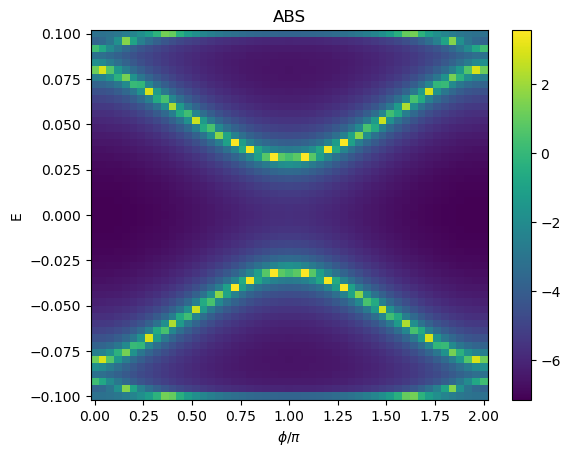

In [1]:
import numpy as np

def AndreevBoundState(Lx, Ulead, UD, Delta, Phi_R, tc, ef):
    # Material Parameters
    lx = int(Lx // 2)  # The certain layer we need to calculate
    # Lead: SC
    t = 1
    Phi_L = 0
    H_L = np.array([[2 * t - Ulead, Delta * np.exp(1j * Phi_L)],
                    [Delta * np.exp(-1j * Phi_L), -(2 * t - Ulead)]])
    H_R = np.array([[2 * t - Ulead, Delta * np.exp(1j * Phi_R)],
                    [Delta * np.exp(-1j * Phi_R), -(2 * t - Ulead)]])
    T_R = np.array([[-t, 0], [0, t]])
    # Device
    H_D = np.array([[2 * t - UD, 0],
                    [0, -(2 * t - UD)]])
    T_D = T_R
    # coupling between D and R-lead
    T_DR = tc * T_D

    # Andreev bound state
    # Surface Green's function
    N = H_D.shape[0]
    EE = (ef + 1j * 1e-4) * np.eye(N)


    # right
    inv_TR = np.linalg.inv(T_R)
    TT_R = np.block([[inv_TR @ (EE - H_R), -inv_TR @ T_R.conj().T],
                     [np.eye(N), np.zeros((N, N))]])
    # ---
    eigenvalues_R, eigenvector_R = np.linalg.eig(TT_R)
    b_R = np.argsort(np.abs(eigenvalues_R))
    v2_R = eigenvector_R[:, b_R]
    S1_R = v2_R[0:N, 0:N]
    S2_R = v2_R[N:2*N, 0:N]
    g_R = np.linalg.inv(EE - H_R - T_R @ S1_R @ np.linalg.inv(S2_R))

    # self energy
    SigmaR = T_DR @ g_R @ T_DR.conj().T



    # GammaR = 1j * (SigmaR - SigmaR.conj().T)  # Commented out as in original
    # left
    inv_TR_dag = np.linalg.inv(T_R.conj().T)
    TT_L = np.block([[inv_TR_dag @ (EE - H_L), -inv_TR_dag @ T_R],
                     [np.eye(N), np.zeros((N, N))]])
    # ---
    eigenvalues_L, eigenvector_L = np.linalg.eig(TT_L)
    b_L = np.argsort(np.abs(eigenvalues_L))
    v2_L = eigenvector_L[:, b_L]
    S1_L = v2_L[0:N, 0:N]
    S2_L = v2_L[N:2*N, 0:N]
    g_L = np.linalg.inv(EE - H_L - T_R.conj().T @ S1_L @ np.linalg.inv(S2_L))

    # self energy
    SigmaL = T_DR.conj().T @ g_L @ T_DR


    # GammaL = 1j * (SigmaL - SigmaL.conj().T)  # Commented out as in original
    # arrange the surface GF to the first and the last layer of the center device
    G11 = np.linalg.inv(EE - H_D - SigmaL)
    GNN = np.linalg.inv(EE - H_D - SigmaR)
    # From surface GF to the GF in a certain column l
    Gii = G11
    for c in range(2, lx):
        Gii = np.linalg.inv(EE - H_D - T_D.conj().T @ Gii @ T_D)
    Gkk = GNN
    for c in range(Lx - 1, lx, -1):
        Gkk = np.linalg.inv(EE - H_D - T_D @ Gkk @ T_D.conj().T)


    Sigma_i = T_D.conj().T @ Gii @ T_D
    Sigma_k = T_D @ Gkk @ T_D.conj().T

    Gll = np.linalg.inv(EE - H_D - Sigma_i - Sigma_k)

    # ABS
    ABS = -1 / np.pi * np.imag(np.trace(Gll))
    
    return ABS

import numpy as np
import matplotlib.pyplot as plt

# Assuming the AndreevBoundState function is defined as previously translated

# Parameters
Lx = 10
Ulead = 1
Delta = 0.1
UD = 0.8
tc = 0.8

# for plot
rk = 1 * Delta
num_ef = 50
efmin = -rk
efmax = rk
def_ = (efmax - efmin) / num_ef


# -------------------
num_phi_R = 50
phi_Rmin = 0
phi_Rmax = 2 * np.pi
dphi_R = (phi_Rmax - phi_Rmin) / num_phi_R


# Hamiltonian
ef_plot = np.zeros(num_ef + 1)
phi_R_plot = np.zeros(num_phi_R + 1)
ABS = np.zeros((num_ef + 1, num_phi_R + 1))

for jj in range(num_ef + 1):
    ef = efmin + def_ * jj
    ef_plot[jj] = ef
    for ii in range(num_phi_R + 1):
        Phi_R = phi_Rmin + dphi_R * ii
        phi_R_plot[ii] = Phi_R / np.pi
        ABS[jj, ii] = AndreevBoundState(Lx, Ulead, UD, Delta, Phi_R, tc, ef)
# Figure
plt.figure()
X, Y = np.meshgrid(phi_R_plot, ef_plot)
plt.pcolormesh(X, Y, np.log(ABS), shading='auto')
plt.colorbar(location='right')
plt.xlabel(r'$\phi$/$\pi$')
plt.ylabel('E')
plt.title('ABS')
plt.axis('square')
plt.axis('tight')
plt.show()

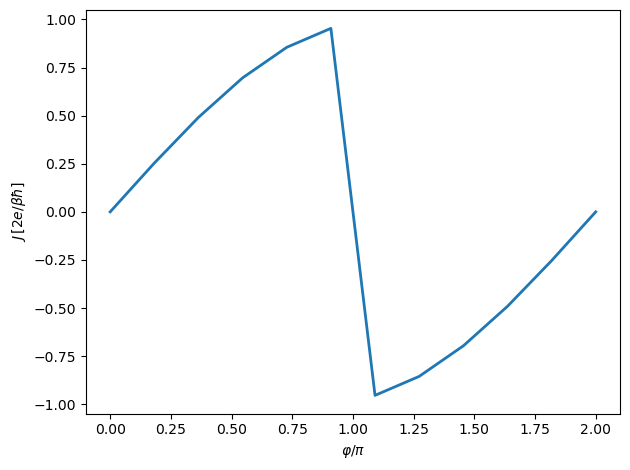

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# =====================================================
# Josephson Current
# =====================================================

def JoseCurrent(Lx, t, Ulead, UD, Delta_0, Phi_R, tc, T_Tc, gamma):

    lx = Lx // 2

    # ---------- Lead ----------
    Phi_L = 0

    Delta = Delta_0 * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

    kBT = 2 * Delta_0 * T_Tc / 3.5

    mmax = int(np.floor(5 / T_Tc))

    H_L = np.array([
        [2*t - Ulead, Delta*np.exp(1j*Phi_L)],
        [Delta*np.exp(-1j*Phi_L), -(2*t - Ulead)]
    ])

    H_R = np.array([
        [2*t - Ulead, Delta*np.exp(1j*Phi_R) + gamma],
        [Delta*np.exp(-1j*Phi_R), -(2*t - Ulead)]
    ])

    T_R = np.array([[-t, 0],
                    [0,  t]])

    # ---------- Device ----------
    H_D = np.array([
        [2*t - UD, 0],
        [0, -(2*t - UD)]
    ])

    T_D = T_R.copy()

    # coupling
    T_DR = tc * T_R

    # =================================================
    # Josephson current
    # =================================================
    current = 0

    N = H_D.shape[0]

    for m in range(-(mmax + 1), mmax + 1):

        ef = 1j * (2*m + 1) * np.pi * kBT * t

        EE = (ef + 1j*1e-6) * np.eye(N)

        # ================= Right lead =================
        inv_TR = np.linalg.inv(T_R)

        TT_R = np.block([
            [inv_TR @ (EE - H_R), -inv_TR @ T_R.conj().T],
            [np.eye(N), np.zeros((N, N))]
        ])

        eigval_R, eigvec_R = np.linalg.eig(TT_R)
        idx = np.argsort(np.abs(eigval_R))

        v = eigvec_R[:, idx]
        S1 = v[:N, :N]
        S2 = v[N:2*N, :N]

        g_R = np.linalg.inv(
            EE - H_R - T_R @ S1 @ np.linalg.inv(S2)
        )

        SigmaR = T_DR @ g_R @ T_DR.conj().T

        # ================= Left lead =================
        inv_TR_dag = np.linalg.inv(T_R.conj().T)

        TT_L = np.block([
            [inv_TR_dag @ (EE - H_L), -inv_TR_dag @ T_R],
            [np.eye(N), np.zeros((N, N))]
        ])

        eigval_L, eigvec_L = np.linalg.eig(TT_L)
        idx = np.argsort(np.abs(eigval_L))

        v = eigvec_L[:, idx]
        S1 = v[:N, :N]
        S2 = v[N:2*N, :N]

        g_L = np.linalg.inv(
            EE - H_L - T_R.conj().T @ S1 @ np.linalg.inv(S2)
        )

        SigmaL = T_DR.conj().T @ g_L @ T_DR

        # ================= Device GF =================
        G11 = np.linalg.inv(EE - H_D - SigmaL)
        GNN = np.linalg.inv(EE - H_D - SigmaR)

        Gii = G11
        for _ in range(2, lx):
            Gii = np.linalg.inv(
                EE - H_D - T_D.conj().T @ Gii @ T_D
            )

        Gkk = GNN
        for _ in range(Lx-1, lx, -1):
            Gkk = np.linalg.inv(
                EE - H_D - T_D @ Gkk @ T_D.conj().T
            )

        Sigma_i = T_D.conj().T @ Gii @ T_D
        Sigma_k = T_D @ Gkk @ T_D.conj().T

        Gll = np.linalg.inv(
            EE - H_D - Sigma_i - Sigma_k
        )

        # ================= Current =================
        GFO_SN = Gll @ T_D.conj().T @ Gii
        GFOD_SN = Gii @ T_D @ Gll

        GFLO = 1j * GFO_SN
        GFLOD = 1j * GFOD_SN

        SIGM0 = np.array([[1, 0],
                          [0, -1]])

        current_matrix = SIGM0 @ (
            T_D @ GFLO - T_D.conj().T @ GFLOD
        )

        dc = np.real(np.trace(current_matrix))

        current += kBT / Delta * dc

    return current


# =====================================================
# Main program
# =====================================================

Lx = 3
t = 1
Ulead = 1*t
Delta_0 = 0.01*t
T_Tc = 0.001
UD = Ulead
tc = 1*t
gamma = 0

# phase sweep
num_phi_R = 11
phi_Rmin = 0
phi_Rmax = 2*np.pi

phi_R_plot = np.zeros(num_phi_R + 1)
J = np.zeros(num_phi_R + 1)

for ii in range(num_phi_R + 1):

    Phi_R = phi_Rmin + (phi_Rmax - phi_Rmin)/num_phi_R * ii

    phi_R_plot[ii] = Phi_R / np.pi

    J[ii] = JoseCurrent(
        Lx, t, Ulead, UD,
        Delta_0, Phi_R,
        tc, T_Tc, gamma
    )

# =====================================================
# Plot
# =====================================================

plt.figure()

plt.plot(phi_R_plot, np.real(J), linewidth=2)

plt.xlabel(r'$\varphi/\pi$')
plt.ylabel(r'$J\,[2e/\beta\hbar]$')

plt.tight_layout()
plt.show()

<>:211: SyntaxWarning: invalid escape sequence '\D'
<>:211: SyntaxWarning: invalid escape sequence '\D'
C:\Users\taoji\AppData\Local\Temp\ipykernel_3796\3908059665.py:211: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('E/$\Delta$')


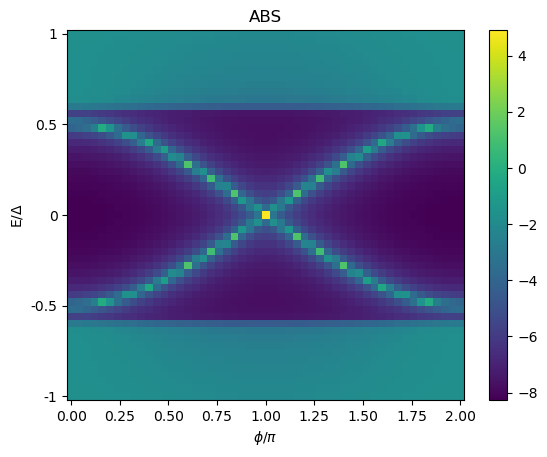

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def make_Hamiltonian(chaodaojiao,saimanjiao):
    sx = np.array([[0, 1], [1, 0]], complex)
    sy = np.array([[0, -1j], [1j, 0]], complex)
    sz = np.array([[1, 0], [0, -1]], complex)
    s0 = np.array([[1, 0], [0, 1]], complex)

    #左边矩阵信息
    HL_block=-(mu-2*t)*s0 + h*np.cos(0)*sx + h*np.sin(0)*sy 
    Delta_L=dela * np.exp(-1j*chaodaojiao/2) * 1j * sy
    H_L_onsite=np.block([
            [ HL_block,        Delta_L        ],
            [ Delta_L.conj().T, -HL_block.conj() ]
        ])
    H_L_right_to_left_hop_block=-1*(t*s0+1j*af*sz/a)
    H_L_right_to_left_hop=np.block([
            [ H_L_right_to_left_hop_block,        np.zeros((2,2))],
            [ np.zeros((2,2)), -H_L_right_to_left_hop_block.conj() ]
        ])

    #中间矩阵信息
    H_center_to_L=np.block([
            [ -t*s0,        np.zeros((2,2)) ],
            [ np.zeros((2,2)) , t*s0 ]
        ])

    H_center_block=(U-mu+2*t)*s0+mz*sz
    H_center=np.block([
            [ H_center_block,        np.zeros((2,2)) ],
            [ np.zeros((2,2)) , -H_center_block.conj()  ]
        ])
        
    H_center_right_to_left_hop=np.block([
            [ -t*s0,        np.zeros((2,2)) ],
            [ np.zeros((2,2)) , t*s0 ]
        ])
    H_R_to_center=np.block([
            [ -t*s0,        np.zeros((2,2)) ],
            [ np.zeros((2,2)) , t*s0 ]
        ])

    #右边矩阵信息
    HR_block=-(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy 
    Delta_R=dela * np.exp(+1j*chaodaojiao/2) * 1j * sy
    H_R_onsite=np.block([
            [ HR_block,        Delta_R        ],
            [ Delta_R.conj().T, -HR_block.conj() ]
        ])
    H_R_right_to_left_hop_block=-1*(t*s0+1j*af/a*sz)
    H_R_right_to_left_hop=np.block([
            [ H_R_right_to_left_hop_block,        np.zeros((2,2))],
            [ np.zeros((2,2)), -H_R_right_to_left_hop_block.conj() ]
        ])

    return {
        "H_L": H_L_onsite,
        "H_R": H_R_onsite,
        "H_D": H_center,

        "T_L": H_L_right_to_left_hop,
        "T_R": H_R_right_to_left_hop.conj().T,
        "T_D": H_center_right_to_left_hop.conj().T,

        "T_DR": H_R_to_center,
        "T_DL": H_center_to_L.conj().T*1
    }


def AndreevBoundState(Lx, Hsys, ef):

    H_L = Hsys["H_L"]
    H_R = Hsys["H_R"]
    H_D = Hsys["H_D"]

    T_L = Hsys["T_L"]
    T_R = Hsys["T_R"]
    T_D = Hsys["T_D"]
    T_DR = Hsys["T_DR"]
    T_DL = Hsys["T_DL"]
    lx = int(Lx // 2)

    N = H_D.shape[0]
    EE = (ef + 1j*1e-4) * np.eye(N)

    # ================= Right surface GF =================
    inv_TR = np.linalg.inv(T_R)

    TT_R = np.block([
        [inv_TR @ (EE - H_R), -inv_TR @ T_R.conj().T],
        [np.eye(N), np.zeros((N, N))]
    ])

    eigval_R, eigvec_R = np.linalg.eig(TT_R)
    idx = np.argsort(np.abs(eigval_R))

    v = eigvec_R[:, idx]
    S1 = v[:N, :N]
    S2 = v[N:2*N, :N]

    g_R = np.linalg.inv(
        EE - H_R - T_R @ S1 @ np.linalg.inv(S2)
    )

    SigmaR = T_DR @ g_R @ T_DR.conj().T

    # ================= Left surface GF =================
    inv_TR_dag = np.linalg.inv(T_R.conj().T)

    TT_L = np.block([
        [inv_TR_dag @ (EE - H_L), -inv_TR_dag @ T_R],
        [np.eye(N), np.zeros((N, N))]
    ])

    eigval_L, eigvec_L = np.linalg.eig(TT_L)
    idx = np.argsort(np.abs(eigval_L))

    v = eigvec_L[:, idx]
    S1 = v[:N, :N]
    S2 = v[N:2*N, :N]

    g_L = np.linalg.inv(
        EE - H_L - T_R.conj().T @ S1 @ np.linalg.inv(S2)
    )

    SigmaL = T_DL @ g_L @ T_DL.conj().T

    # ================= Device Green Function =================
    G11 = np.linalg.inv(EE - H_D - SigmaL)
    GNN = np.linalg.inv(EE - H_D - SigmaR)

    # Dyson propagation
    Gii = G11
    for _ in range(2, lx):
        Gii = np.linalg.inv(
            EE - H_D - T_D.conj().T @ Gii @ T_D
        )

    Gkk = GNN
    for _ in range(Lx-1, lx, -1):
        Gkk = np.linalg.inv(
            EE - H_D - T_D @ Gkk @ T_D.conj().T
        )

    Sigma_i = T_D.conj().T @ Gii @ T_D
    Sigma_k = T_D @ Gkk @ T_D.conj().T

    Gll = np.linalg.inv(
        EE - H_D - Sigma_i - Sigma_k
    )

    # Local DOS (ABS spectrum)
    ABS = -1/np.pi * np.imag(np.trace(Gll))

    return ABS


# =====================================================
# 3. Simulation Parameters

dela = 0.1875
t = 38*dela
af =1
a = 1
U = 1.9*dela
mz = 0*dela
mu = 8*dela
hc=1.2#100
h =hc * np.sqrt(mu**2 + dela**2)
saimanjiao=0

rk = dela
num_ef = 50
efmin = -rk
efmax = rk

num_phi_R = 50
phi_Rmin = 0
phi_Rmax = 2*np.pi

# arrays
ef_plot = np.linspace(efmin, efmax, num_ef+1)
phi_R_plot = np.linspace(phi_Rmin, phi_Rmax, num_phi_R+1)/np.pi

ABS = np.zeros((num_ef+1, num_phi_R+1))




for jj, ef in enumerate(ef_plot):

    for ii, Phi_R in enumerate(np.linspace(phi_Rmin, phi_Rmax, num_phi_R+1)):

        # build Hamiltonian
        Hsys = make_Hamiltonian(Phi_R,saimanjiao)
        ABS[jj, ii] = AndreevBoundState(Lx, Hsys, ef)





plt.figure()

X, Y = np.meshgrid(phi_R_plot, ef_plot)

plt.pcolormesh(X, Y, np.log(ABS + 1e-12), shading='auto')
plt.colorbar(location='right')

plt.xlabel(r'$\phi/\pi$')
plt.ylabel('E/$\Delta$')
plt.yticks(
    [-dela, -dela/2, 0, dela/2, dela],
    [-1, -0.5, 0, 0.5, 1]
)
plt.title('ABS')

plt.axis('square')
plt.axis('tight')

plt.show()

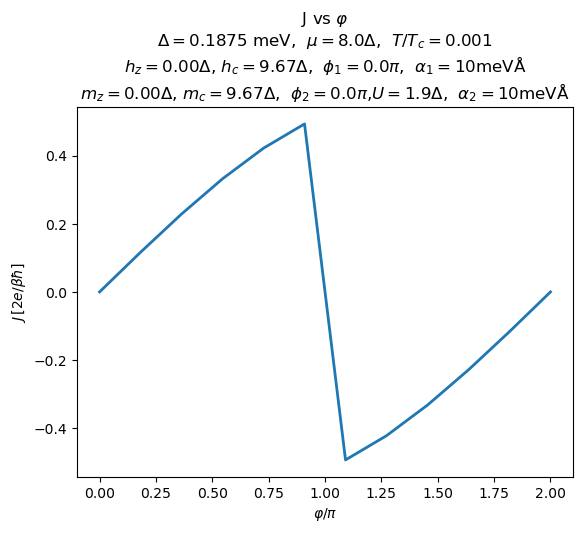

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def make_Hamiltonian(chaodaojiao,saimanjiao):
        
    #矩阵信息
    sx = np.array([[0, 1], [1, 0]], complex)
    sy = np.array([[0, -1j], [1j, 0]], complex)
    sz = np.array([[1, 0], [0, -1]], complex)
    s0 = np.array([[1, 0], [0, 1]], complex)

    #左边矩阵信息
    HL_block=-(mu-2*t)*s0 + h*np.cos(0)*sx + h*np.sin(0)*sy +hz*sz
    Delta_L=Delta * np.exp(-1j*chaodaojiao/2) * 1j * sy
    H_L_onsite=np.block([
            [ HL_block,        Delta_L        ],
            [ Delta_L.conj().T, -HL_block.conj() ]
        ])
    H_L_right_to_left_hop_block=-1*(t*s0+1j*af*sz/a)
    H_L_right_to_left_hop=np.block([
            [ H_L_right_to_left_hop_block,        np.zeros((2,2))],
            [ np.zeros((2,2)), -H_L_right_to_left_hop_block.conj() ]
        ])

    #中间矩阵信息
    H_center_to_L=np.block([
            [ -1*t*s0,        np.zeros((2,2)) ],
            [ np.zeros((2,2)) , t*s0 ]
        ])


    H_center_block=(U-mu+2*t)*s0 + mz*sz + m*np.cos(zhongjian_saimanjiao)*sx + m*np.sin(zhongjian_saimanjiao)*sy
    H_center=np.block([
            [ H_center_block,        np.zeros((2,2)) ],
            [ np.zeros((2,2)) , -H_center_block.conj()  ]
        ])


    H_center_right_to_left_hop_block=-1*(t*s0+1j*af*sz*af6666/a)
    H_center_right_to_left_hop=np.block([
            [ H_center_right_to_left_hop_block,        np.zeros((2,2)) ],
            [ np.zeros((2,2)) , -H_center_right_to_left_hop_block.conj() ]
        ])


    H_R_to_center=np.block([
            [ -t*s0,        np.zeros((2,2)) ],
            [ np.zeros((2,2)) , t*s0 ]
        ])

    #右边矩阵信息
    HR_block=-(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy +hz*sz
    Delta_R=Delta * np.exp(+1j*chaodaojiao/2) * 1j * sy
    H_R_onsite=np.block([
            [ HR_block,        Delta_R        ],
            [ Delta_R.conj().T, -HR_block.conj() ]
        ])
    H_R_right_to_left_hop_block=-1*(t*s0+1j*af/a*sz)
    H_R_right_to_left_hop=np.block([
            [ H_R_right_to_left_hop_block,        np.zeros((2,2))],
            [ np.zeros((2,2)), -H_R_right_to_left_hop_block.conj() ]
        ])

    return {
        "H_L": H_L_onsite,
        "H_R": H_R_onsite,
        "H_D": H_center,

        "T_L": H_L_right_to_left_hop,
        "T_R": H_R_right_to_left_hop.conj().T,
        "T_D": H_center_right_to_left_hop.conj().T,

        "T_DR": H_R_to_center*1,
        "T_DL": H_center_to_L.conj().T*1

    }


def JoseCurrent(Lx, Hsys, dela, T_Tc):

    H_L = Hsys["H_L"]
    H_R = Hsys["H_R"]
    H_D = Hsys["H_D"]

    T_L = Hsys["T_L"]
    T_R = Hsys["T_R"]
    T_D = Hsys["T_D"]
    T_DR = Hsys["T_DR"]
    T_DL = Hsys["T_DL"]

    lx = Lx // 2

    # temperature
    Delta = dela * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

    kBT = 2 * dela * T_Tc / 3.5
    mmax = int(np.floor(5 / T_Tc))

    current = 0
    N = H_D.shape[0]

    for m in range(-(mmax + 1), mmax + 1):

        ef = 1j * (2*m + 1) * np.pi * kBT
        #EE = (ef + 1j*1e-6) * np.eye(N)
        EE = (ef ) * np.eye(N)
        # ================= Right Lead =================
        inv_TR = np.linalg.inv(T_R)

        TT_R = np.block([
            [inv_TR @ (EE - H_R), -inv_TR @ T_R.conj().T],
            [np.eye(N), np.zeros((N, N))]
        ])

        eigval, eigvec = np.linalg.eig(TT_R)
        idx = np.argsort(np.abs(eigval))

        v = eigvec[:, idx]
        S1 = v[:N, :N]
        S2 = v[N:2*N, :N]

        g_R = np.linalg.inv(
            EE - H_R - T_R @ S1 @ np.linalg.inv(S2)
        )

        SigmaR = T_DR @ g_R @ T_DR.conj().T

        # ================= Left Lead =================
        inv_TR_dag = np.linalg.inv(T_R.conj().T)

        TT_L = np.block([
            [inv_TR_dag @ (EE - H_L), -inv_TR_dag @ T_R],
            [np.eye(N), np.zeros((N, N))]
        ])

        eigval, eigvec = np.linalg.eig(TT_L)
        idx = np.argsort(np.abs(eigval))

        v = eigvec[:, idx]
        S1 = v[:N, :N]
        S2 = v[N:2*N, :N]

        g_L = np.linalg.inv(
            EE - H_L - T_R.conj().T @ S1 @ np.linalg.inv(S2)
        )

        SigmaL = T_DL @ g_L @ T_DL.conj().T

        # ================= Device Green Function =================
        G11 = np.linalg.inv(EE - H_D - SigmaL)
        GNN = np.linalg.inv(EE - H_D - SigmaR)

        Gii = G11
        for _ in range(2, lx):
            Gii = np.linalg.inv(
                EE - H_D - T_D.conj().T @ Gii @ T_D
            )

        Gkk = GNN
        for _ in range(Lx-1, lx, -1):
            Gkk = np.linalg.inv(
                EE - H_D - T_D @ Gkk @ T_D.conj().T
            )

        Sigma_i = T_D.conj().T @ Gii @ T_D
        Sigma_k = T_D @ Gkk @ T_D.conj().T

        Gll = np.linalg.inv(
            EE - H_D - Sigma_i - Sigma_k
        )

        # ================= Current Operator =================
        GFO_SN = Gll @ T_D.conj().T @ Gii
        GFOD_SN = Gii @ T_D @ Gll

        SIGM0 = np.array([[1,0,0,0],[0,1,0,0],[0,0,-1,0],
                          [0,0,0,-1]])

        current_matrix = SIGM0 @ (
            T_D @ (1j * GFO_SN)
            - T_D.conj().T @ (1j * GFOD_SN)
        )

        dc = np.real(np.trace(current_matrix))

        current += kBT / Delta * dc

    return current



#参数
dela = 0.1875
t = 38*dela
af =1
a = 1
mu = 8*dela



mz = 0*dela
hc=1.2#100
h =hc * np.sqrt(mu**2 + dela**2)
saimanjiao=np.pi*0

hz=0
U = 1.9*dela
mc=1
m =  h*mc
zhongjian_saimanjiao=np.pi*0
af6666=1



T_Tc=0.001
Delta = dela * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))
Lx=10
num_phi_R = 11

phi_R_plot = np.zeros(num_phi_R + 1)
J = np.zeros(num_phi_R + 1)


for ii in range(num_phi_R + 1):

    Phi_R = 2 * np.pi * ii / num_phi_R
    phi_R_plot[ii] = Phi_R / np.pi

    Hsys = make_Hamiltonian( Phi_R,saimanjiao)

    J[ii] = JoseCurrent(
        Lx, Hsys,
        dela, T_Tc
    )



plt.figure()

plt.plot(phi_R_plot, J, linewidth=2)

plt.xlabel(r'$\varphi/\pi$')
plt.ylabel(r'$J\,[2e/\beta\hbar]$')

plt.axis('tight')
plt.title(
    f'J vs $\\varphi$\n'
    f'$\\Delta = {dela:.4f}$ meV,  $\\mu = {mu/dela:.1f}\\Delta$,  $T/T_c = {T_Tc}$\n'
    f'$h_z = {hz/dela:.2f}\\Delta$, $h_c = {h/dela:.2f}\\Delta$,  $\\phi_1 = {saimanjiao / np.pi:.1f}\\pi$,  $\\alpha_1 = {af*10}$meVÅ\n'
    f'$m_z = {mz/dela:.2f}\\Delta$, $m_c = {m/dela:.2f}\\Delta$,  $\\phi_2 = {zhongjian_saimanjiao / np.pi:.1f}\\pi$,$U = {U/dela:.1f}\\Delta$,  $\\alpha_2 = {af*af6666*10}$meVÅ'
)
plt.show()

In [ ]:
from scipy.optimize import fmin
import numpy as np

def find_J_extrema(Lx, dela, T_Tc, saimanjiao,
                   n_guess=4,xtol=1e-6, ftol=1e-6,
                   round_digits=6):

    # -------- Josephson current as function --------
    def J_of_phi(phi):

        Hsys = make_Hamiltonian(phi, saimanjiao)

        return JoseCurrent(
            Lx,
            Hsys,
            dela,
            T_Tc
        )

    # -------- initial guesses in [0,2π] --------
    phi_guesses = np.linspace(0, 2*np.pi, n_guess)

    phi_max_list = []
    phi_min_list = []

    for phi0 in phi_guesses:

        # 最大值
        phi_max = fmin(
            lambda x: -J_of_phi(x[0]),
            [phi0],
            disp=False,xtol=xtol, ftol=ftol
        )[0]

        # 最小值
        phi_min = fmin(
            lambda x: J_of_phi(x[0]),
            [phi0],
            disp=False,xtol=xtol, ftol=ftol
        )[0]

        phi_max_list.append(phi_max)
        phi_min_list.append(phi_min)

    # -------- remove duplicates --------
    phi_max_unique = np.unique(np.round(phi_max_list, round_digits))
    phi_min_unique = np.unique(np.round(phi_min_list, round_digits))

    # -------- evaluate J --------
    J_max = np.max([J_of_phi(phi) for phi in phi_max_unique])
    J_min = np.min([J_of_phi(phi) for phi in phi_min_unique])
    
    yinzi=(abs(J_max)-abs(J_min))/(abs(J_max)+abs(J_min))
    return J_max, J_min, yinzi
find_J_extrema(Lx, dela, T_Tc, saimanjiao)

mz = -0.562, yinzi = 0.000198
mz = -0.450, yinzi = 0.000406
mz = -0.338, yinzi = 0.000353
mz = -0.225, yinzi = 0.000238
mz = -0.112, yinzi = 0.000117
mz = 0.000, yinzi = 0.000000
mz = 0.113, yinzi = -0.000117
mz = 0.225, yinzi = -0.000238
mz = 0.338, yinzi = -0.000353
mz = 0.450, yinzi = -0.000406
mz = 0.562, yinzi = -0.000198


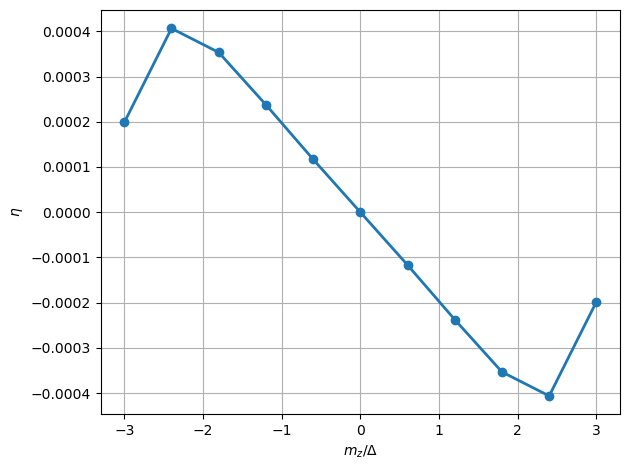

In [ ]:

mz_list = np.linspace(-3*dela, 3*dela, 11)
yinzi_list = np.zeros(len(mz_list))

for i, mz_val in enumerate(mz_list):
    hz=0
    mz = mz_val

    J_max, J_min, yinzi = find_J_extrema(
        Lx,
        dela,
        T_Tc,
        saimanjiao
    )

    yinzi_list[i] = yinzi

    print(f"mz = {mz_val:.3f}, yinzi = {yinzi:.6f}")



plt.figure()

plt.plot(mz_list/dela, yinzi_list, 'o-', linewidth=2)

plt.xlabel(r'$m_z$/$\Delta$')
plt.ylabel(r'$\eta$')

plt.grid(True)
plt.tight_layout()
plt.show()

hz = -0.562, yinzi = -0.000134
hz = -0.450, yinzi = -0.000195
hz = -0.338, yinzi = -0.000266
hz = -0.225, yinzi = -0.000306
hz = -0.112, yinzi = -0.000223
hz = 0.000, yinzi = 0.000000
hz = 0.113, yinzi = 0.000223
hz = 0.225, yinzi = 0.000306
hz = 0.338, yinzi = 0.000266
hz = 0.450, yinzi = 0.000195
hz = 0.562, yinzi = 0.000134


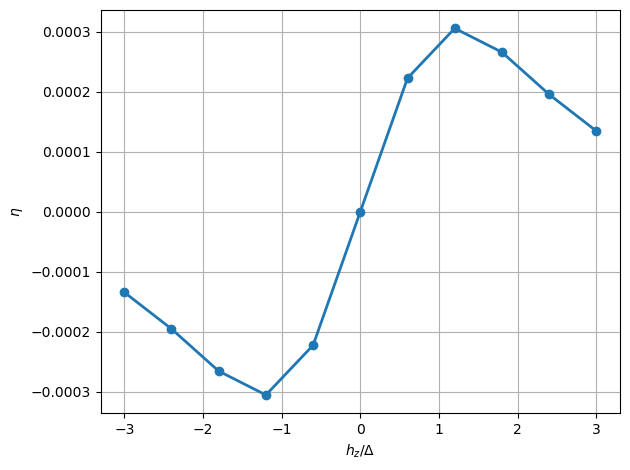

In [ ]:

hz_list = np.linspace(-3*dela, 3*dela, 11)
yinzi_list = np.zeros(len(hz_list))

for i, hz_val in enumerate(hz_list):
    mz=0
    hz = hz_val

    J_max, J_min, yinzi = find_J_extrema(
        Lx,
        dela,
        T_Tc,
        saimanjiao
    )

    yinzi_list[i] = yinzi

    print(f"hz = {hz_val:.3f}, yinzi = {yinzi:.6f}")


plt.figure()

plt.plot(hz_list/dela, yinzi_list, 'o-', linewidth=2)

plt.xlabel(r'$h_z$/$\Delta$')
plt.ylabel(r'$\eta$')

plt.grid(True)
plt.tight_layout()
plt.show()